In [1]:
import sys
import os
import pandas as pd

sys.path.append(os.path.abspath(os.path.join('..')))
from src.data.connection import get_db_connection


conn = get_db_connection()

if conn:
    query_tables = "SELECT table_name FROM information_schema.tables WHERE table_schema = 'raw';"
    tables = pd.read_sql(query_tables, conn)['table_name'].tolist()
    
    data = {}

    for table in tables:
        data[table] = pd.read_sql(f"SELECT * FROM raw.{table}", conn)
        print(f"Таблица '{table}' загружена! (строк: {len(data[table])})")
    
    conn.close()
else:
    print("Ошибка подключения к СУБД")



Успешно: Подключение к СУБД установлено.
Таблица 'year' загружена! (строк: 60)
Таблица 'доступность' загружена! (строк: 12)
Таблица 'bank_db' загружена! (строк: 36)
Таблица 'app' загружена! (строк: 12)


C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_14112\2392872286.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(query_tables, conn)['table_name'].tolist()
C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_14112\2392872286.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data[table] = pd.read_sql(f"SELECT * FROM raw.{table}", conn)


In [2]:
model=data['year']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ====== 1. ЗАГРУЗКА ДАННЫХ ======
# Замените имя файла на своё: .csv или .xlsx


# ====== 2. ОЧИСТКА СТОЛБЦОВ ======
model.columns = model.columns.str.strip()

# если у вас есть лишние пробелы в названиях
rename_map = {
    "op_expence ": "op_expence",
    "capital ": "capital",
    "loan ": "loan",
    "deposit": "deposit",
    "FX income": "FX_income",
    "(К 2,1)": "K_2_1",
    "%income": "pct_income",
    "%expence": "pct_expence",
    "net%income": "net_pct_income",
    "net_com_income": "net_com_income",
    "com_income": "com_income",
    "com_outcome": "com_outcome",
    "net_profit": "net_profit",
    "assets": "assets",
    "NPL": "NPL"
}
model = model.rename(columns=rename_map)

# ====== 3. ПОДГОТОВКА ЧИСЛОВЫХ ДАННЫХ ======
target_cols = [
    "pct_income", "pct_expence", "net_pct_income", "com_income",
    "com_outcome", "net_com_income", "FX_income", "op_expence",
    "net_profit", "loan", "deposit", "assets", "capital", "K_2_1", "NPL"
]

for c in target_cols + ["year"]:
    model[c] = (
        model[c]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace(" ", "", regex=False)
    )
    model[c] = pd.to_numeric(model[c], errors="coerce")

model["bank"] = model["bank"].astype(str).str.strip()

# ====== 4. ФУНКЦИЯ ПРОГНОЗА ПО ОДНОМУ БАНКУ ======
def forecast_bank(group):
    group = group.sort_values("year").copy()
    X = group[["year"]].values

    preds = {"bank": group["bank"].iloc[0], "year": 2026}

    for col in target_cols:
        y = group[col].values

        valid = ~np.isnan(y) & ~np.isnan(X[:, 0])
        X_train = X[valid]
        y_train = y[valid]

        if len(y_train) < 2:
            preds[col] = np.nan
            continue

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("ridge", Ridge(alpha=1.0))
        ])

        model.fit(X_train, y_train)
        preds[col] = float(model.predict(np.array([[2026]]))[0])

    return preds

# ====== 5. ПРОГНОЗ ДЛЯ ВСЕХ БАНКОВ ======
forecast_rows = []
for bank_name, grp in model.groupby("bank"):
    forecast_rows.append(forecast_bank(grp))

forecast_df = pd.DataFrame(forecast_rows)

# ====== 6. СОХРАНЕНИЕ РЕЗУЛЬТАТА ======

# ====== 7. ПРОСМОТР РЕЗУЛЬТАТА ======
forecast_df

,bank,year,pct_income,pct_expence,net_pct_income,com_income,com_outcome,net_com_income,FX_income,op_expence,net_profit,loan,deposit,assets,capital,K_2_1,NPL
0,Bakai Bank,2026,6.943123e+06,2.485458e+06,4.457665e+06,3.302994e+06,3.720686e+06,-4.176921e+05,9.654244e+06,1.042631e+07,3.726915e+06,4.727227e+07,1.066414e+08,1.335753e+08,1.459962e+07,14.067273,2.847017e+06
1,Demir Bank,2026,5.922504e+06,1.692884e+06,4.229620e+06,1.197985e+06,1.073796e+06,1.241890e+05,1.255937e+06,3.653633e+06,2.638831e+06,3.952967e+07,6.577928e+07,8.884751e+07,1.332697e+07,18.865455,8.521189e+05
2,Doscredo,2026,2.284898e+06,1.091737e+06,1.193161e+06,5.275448e+05,3.860821e+05,1.414627e+05,7.762578e+05,9.247704e+06,2.244714e+05,1.057585e+07,4.741104e+06,1.809146e+07,2.038945e+06,12.990909,3.866163e+05
3,Eldik,2026,1.130035e+07,8.034420e+05,1.049690e+07,2.424932e+06,1.413089e+06,1.011843e+06,5.271086e+06,5.938806e+06,6.702298e+06,5.882258e+07,1.453448e+08,2.399137e+08,6.737611e+07,51.809091,2.410081e+06
4,KICB,2026,7.178671e+06,2.510702e+06,4.667968e+06,1.326659e+06,8.061273e+05,5.205316e+05,1.937817e+06,3.789920e+06,2.969323e+06,3.203701e+07,7.911843e+07,9.734810e+07,1.317115e+07,17.183871,5.216644e+05
5,MBank,2026,9.298073e+06,6.993896e+06,2.304177e+06,8.195018e+06,5.574591e+06,2.620428e+06,1.001275e+07,9.322645e+06,9.394647e+06,8.327664e+07,1.297621e+08,1.767489e+08,2.515356e+07,21.905455,2.022790e+06
6,Obank,2026,3.351640e+06,1.615133e+06,1.736508e+06,1.113750e+06,9.578612e+05,1.558893e+05,3.640025e+05,1.975340e+06,1.646223e+05,1.418437e+07,2.599235e+07,3.336621e+07,4.988815e+06,16.829091,1.313099e+06
7,Optima,2026,6.227460e+06,1.074995e+06,5.152465e+06,2.597000e+06,1.820954e+06,7.760452e+05,3.007338e+06,5.666073e+06,3.063658e+06,3.640831e+07,5.408643e+07,7.511424e+07,1.604694e+07,-39.332727,5.307097e+06
8,Айыл,2026,1.582592e+07,6.412497e+06,9.413420e+06,3.358498e+06,2.376451e+06,9.820477e+05,4.927723e+06,5.623651e+06,1.031467e+07,7.823612e+07,1.658873e+08,2.289048e+08,2.501159e+07,27.668727,2.121136e+06
9,Бай Тушум,2026,1.879493e+06,9.369072e+05,9.425856e+05,3.828973e+05,2.585967e+05,1.243006e+05,5.562507e+05,1.509903e+06,1.279456e+05,9.881729e+06,1.129034e+07,1.381267e+07,1.768815e+06,14.189091,2.338486e+05


C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_14112\3760837774.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_profit, y='bank', x='net_profit', palette='viridis')


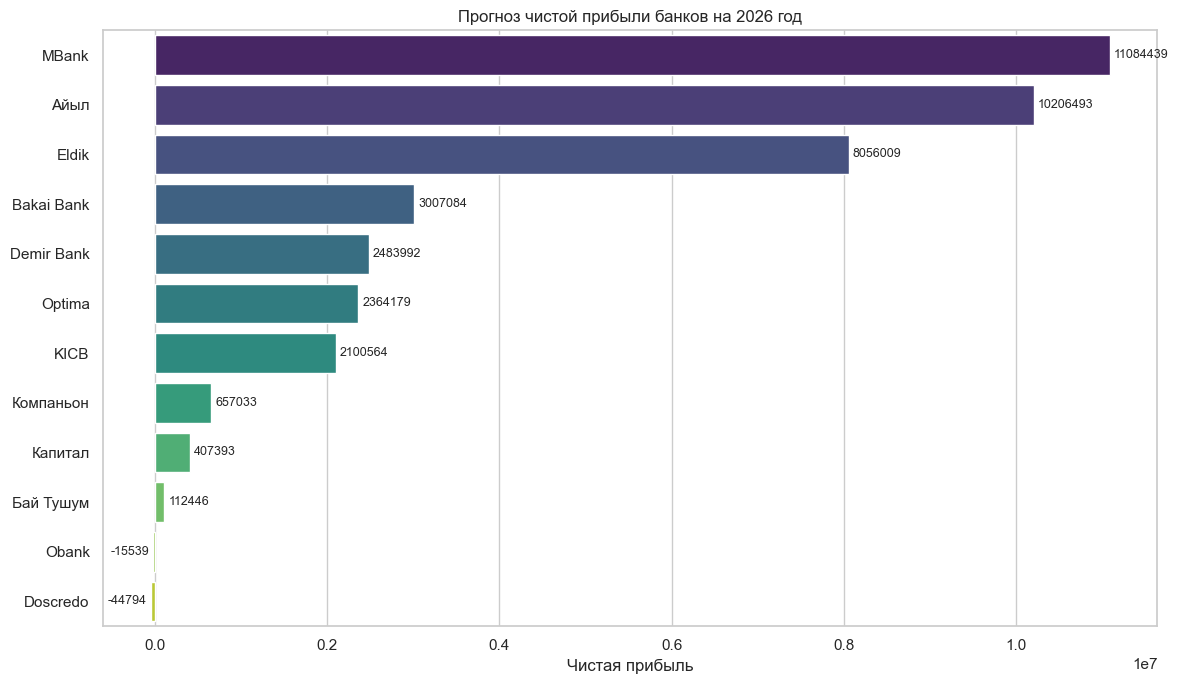

C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_14112\3760837774.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_assets, y='bank', x='assets', palette='mako')


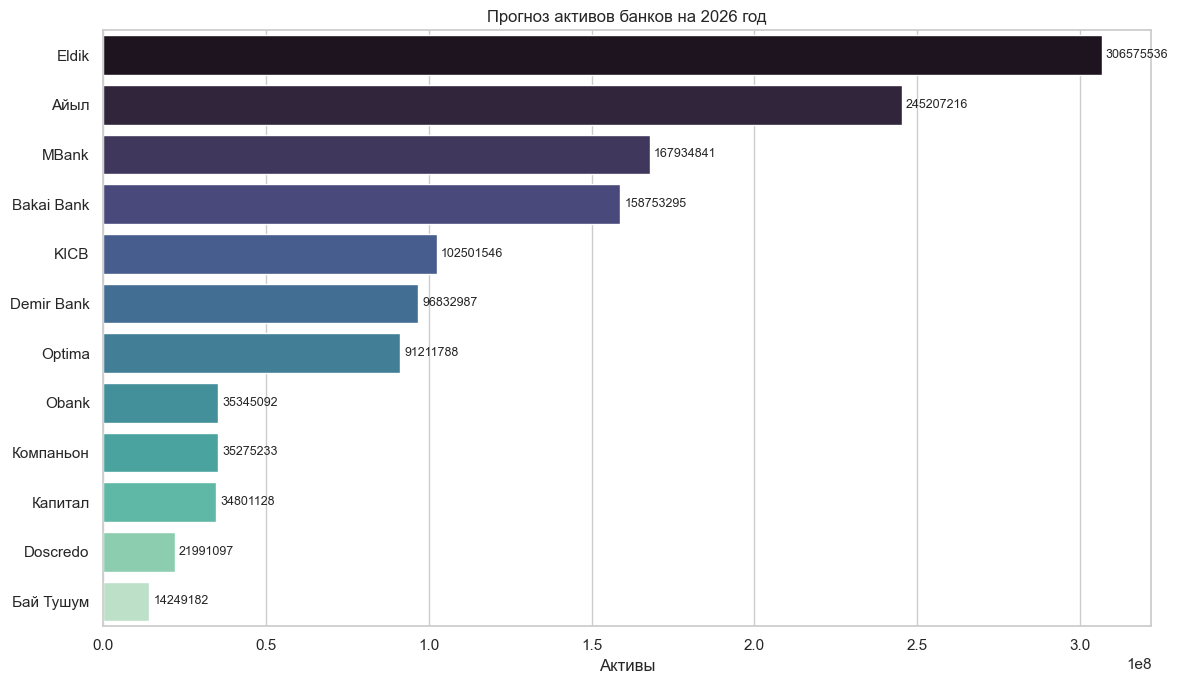

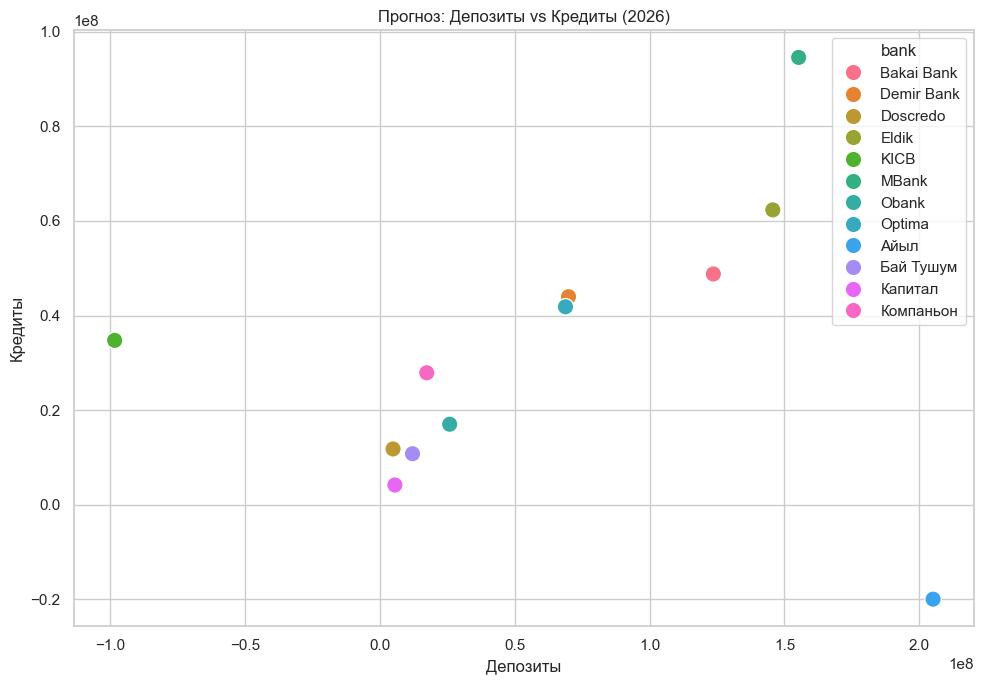

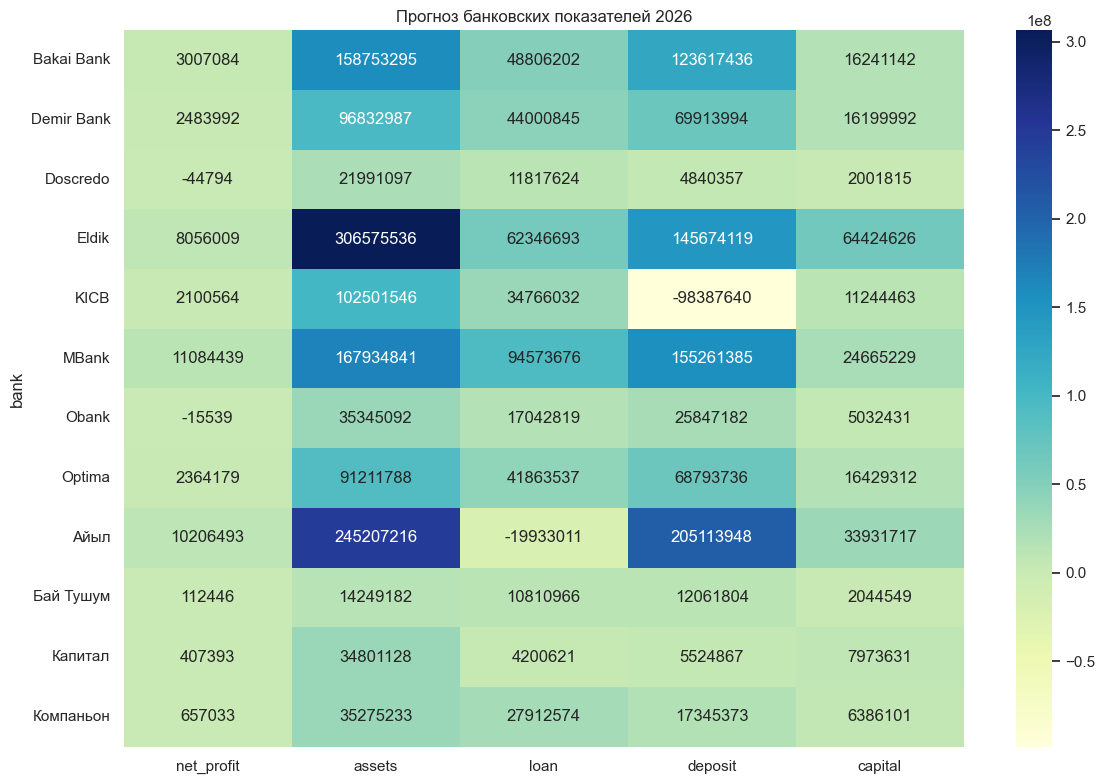

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

# ---------------------------------
# forecast_df уже готов
# ---------------------------------

# 1. ТОП банков по прогнозной прибыли 2026
top_profit = forecast_df.sort_values('net_profit', ascending=False)

plt.figure(figsize=(12,7))
ax = sns.barplot(data=top_profit, y='bank', x='net_profit', palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)

plt.title('Прогноз чистой прибыли банков на 2026 год')
plt.xlabel('Чистая прибыль')
plt.ylabel('')
plt.tight_layout()
plt.show()


# ---------------------------------
# 2. ТОП банков по активам 2026
# ---------------------------------

top_assets = forecast_df.sort_values('assets', ascending=False)

plt.figure(figsize=(12,7))
ax = sns.barplot(data=top_assets, y='bank', x='assets', palette='mako')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)

plt.title('Прогноз активов банков на 2026 год')
plt.xlabel('Активы')
plt.ylabel('')
plt.tight_layout()
plt.show()


# ---------------------------------
# 3. Loans vs Deposits
# ---------------------------------

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=forecast_df,
    x='deposit',
    y='loan',
    hue='bank',
    s=140
)

plt.title('Прогноз: Депозиты vs Кредиты (2026)')
plt.xlabel('Депозиты')
plt.ylabel('Кредиты')
plt.tight_layout()
plt.show()


# ---------------------------------
# 4. Heatmap прогнозных метрик
# ---------------------------------

heat = forecast_df.set_index('bank')[[
    'net_profit',
    'assets',
    'loan',
    'deposit',
    'capital'
]]

plt.figure(figsize=(12,8))
sns.heatmap(heat, cmap='YlGnBu', annot=True, fmt='.0f')

plt.title('Прогноз банковских показателей 2026')
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import numpy as np

from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error

# ---------------------------------
# ДАННЫЕ
# model = твой DataFrame
# ---------------------------------

model.columns = model.columns.str.strip()

# ---------------------------------
# ЦЕЛЕВЫЕ КОЛОНКИ
# ---------------------------------

target_cols = [
    "pct_income", "pct_expence", "net_pct_income", "com_income",
    "com_outcome", "net_com_income", "FX_income", "op_expence",
    "net_profit", "loan", "deposit", "assets", "capital", "K_2_1", "NPL"
]

# ---------------------------------
# МОДЕЛИ
# ---------------------------------

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    )
}

# ---------------------------------
# ФУНКЦИЯ ВЫБОРА ЛУЧШЕЙ МОДЕЛИ
# ---------------------------------

def best_model_forecast(group):

    group = group.sort_values("year").copy()
    X = group[["year"]].values

    result = {
        "bank": group["bank"].iloc[0],
        "year": 2026
    }

    for col in target_cols:

        y = group[col].values

        valid = ~np.isnan(y)
        Xv = X[valid]
        yv = y[valid]

        if len(yv) < 3:
            result[col] = np.nan
            continue

        # train = все кроме последнего года
        X_train = Xv[:-1]
        y_train = yv[:-1]

        X_test = Xv[-1:].reshape(-1,1)
        y_test = yv[-1:]

        best_name = None
        best_mae = np.inf
        best_model = None

        for name, algo in models.items():

            pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="mean")),
                ("model", algo)
            ])

            pipe.fit(X_train, y_train)
            pred = pipe.predict(X_test)[0]

            mae = abs(y_test[0] - pred)

            if mae < best_mae:
                best_mae = mae
                best_name = name
                best_model = pipe

        # обучаем на всех данных
        best_model.fit(Xv, yv)

        forecast = best_model.predict(np.array([[2026]]))[0]

        result[col] = forecast
        result[f"{col}_model"] = best_name

    return result

# ---------------------------------
# ПРОГНОЗ ВСЕХ БАНКОВ
# ---------------------------------

rows = []

for bank_name, grp in model.groupby("bank"):
    rows.append(best_model_forecast(grp))

forecast_df = pd.DataFrame(rows)

# ---------------------------------
# СОХРАНЕНИЕ
# ---------------------------------

forecast_df.to_csv("forecast_best_models_2026.csv", index=False)

# ---------------------------------
# РЕЗУЛЬТАТ
# ---------------------------------

print(forecast_df.head())

         bank  year   pct_income pct_income_model   pct_expence  \
0  Bakai Bank  2026   7283047.10           Linear  1.877185e+06   
1  Demir Bank  2026   6192818.00           Linear  1.778060e+06   
2    Doscredo  2026   2383452.40           Linear  1.091737e+06   
3       Eldik  2026  11842337.30           Linear  4.401999e+06   
4        KICB  2026   7754194.25            Lasso  2.680584e+06   

  pct_expence_model  net_pct_income net_pct_income_model    com_income  \
0  GradientBoosting    4.682128e+06     GradientBoosting  3.302994e+06   
1            Linear    4.414758e+06               Linear  1.019586e+06   
2             Ridge    1.242959e+06               Linear  5.417147e+05   
3  GradientBoosting    6.402297e+06     GradientBoosting  2.424932e+06   
4            Linear    4.667968e+06                Ridge  1.108312e+06   

   com_income_model  ...       deposit     deposit_model        assets  \
0             Ridge  ...  1.117780e+08            Linear  1.397864e+08   
1  G

C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_14112\2665343104.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


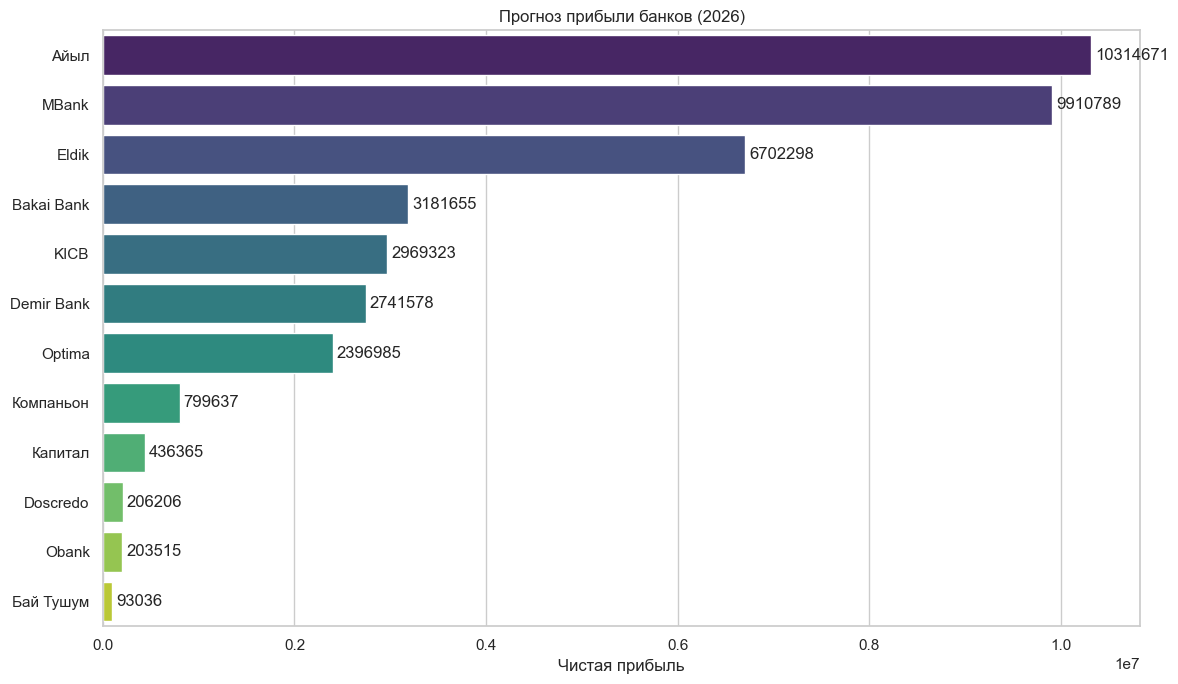

C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_14112\2665343104.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


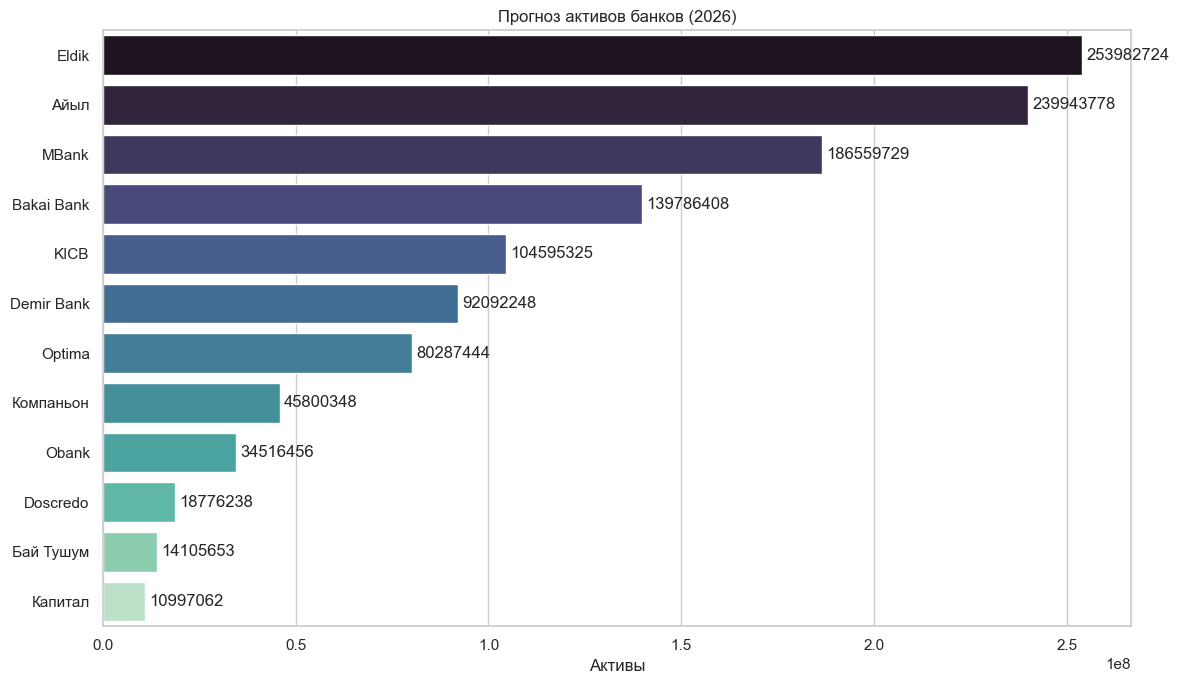

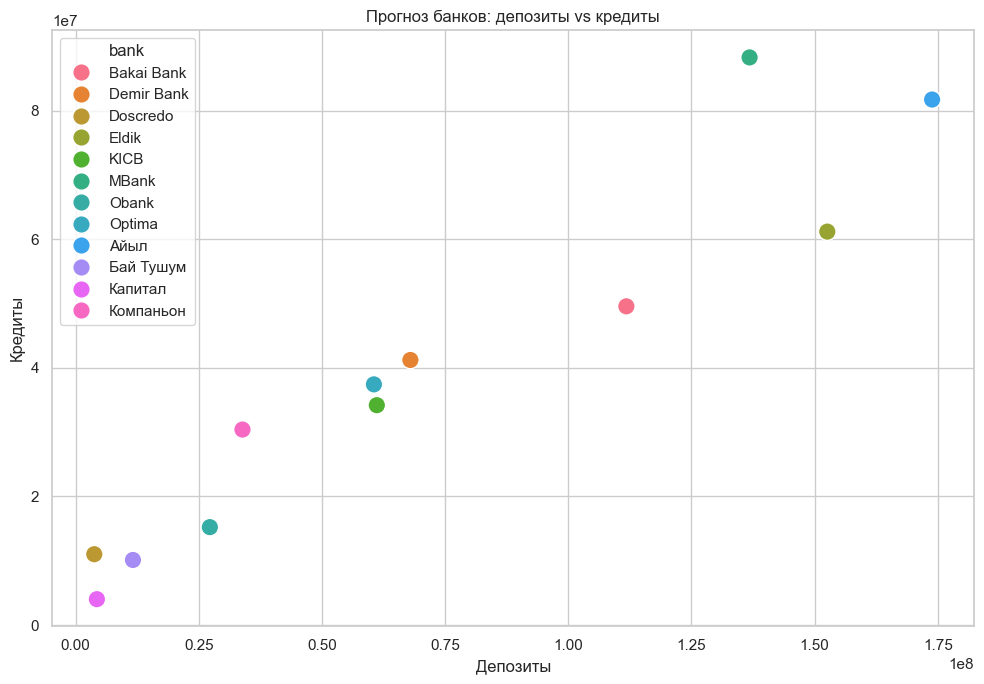

C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_14112\2665343104.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


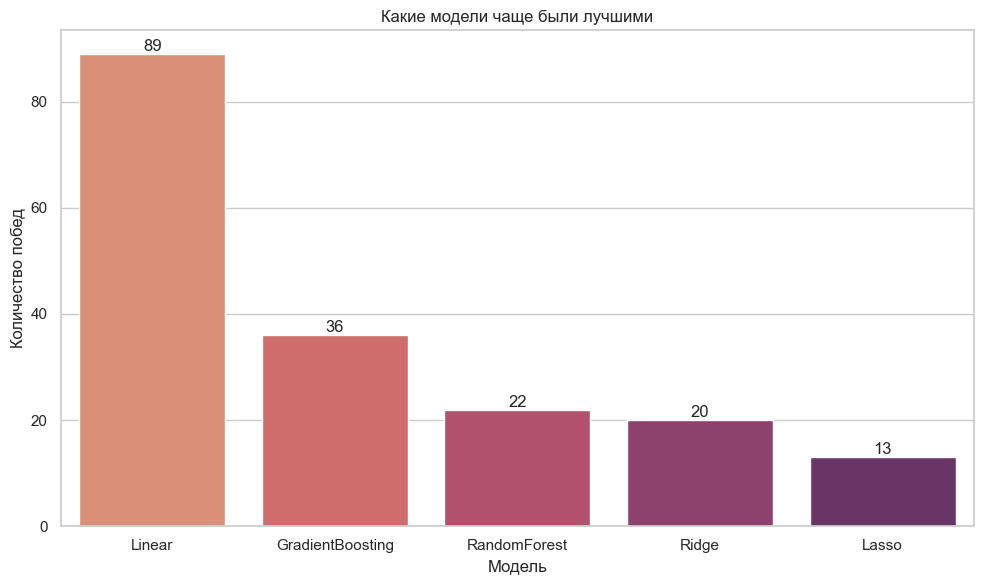

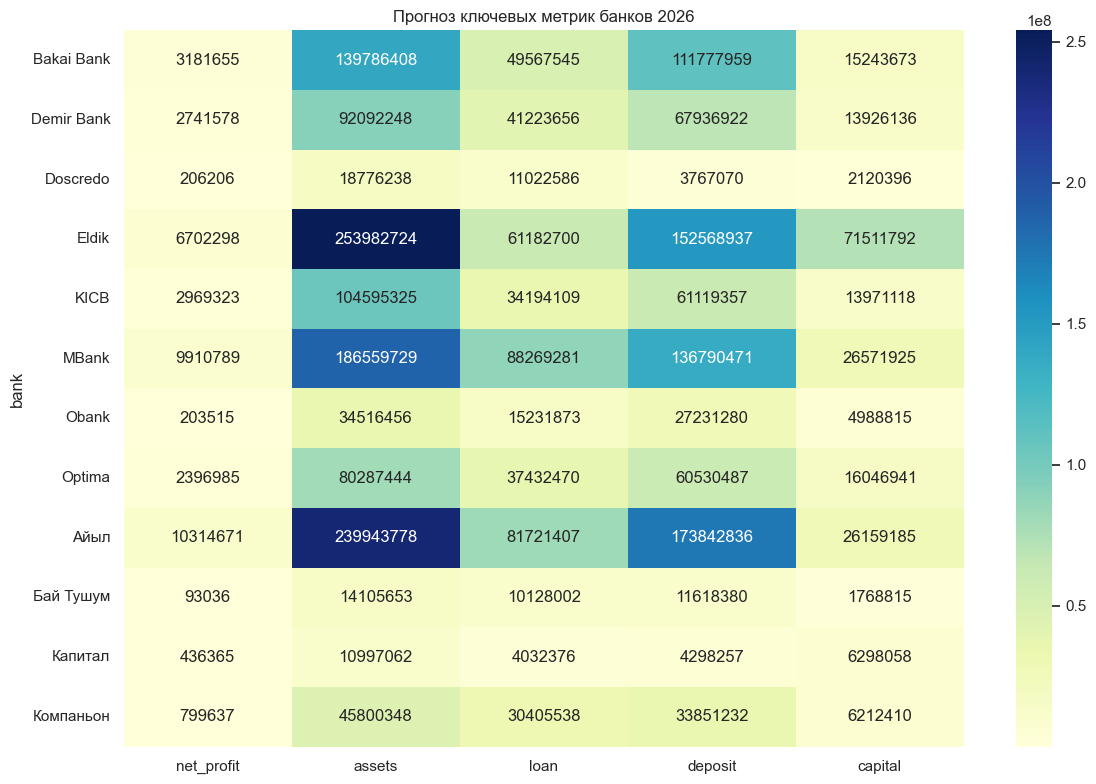

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

# ---------------------------------
# forecast_df = прогноз лучших моделей
# ---------------------------------

# 1. ТОП прибыль 2026
top_profit = forecast_df.sort_values("net_profit", ascending=False)

plt.figure(figsize=(12,7))
ax = sns.barplot(
    data=top_profit,
    y="bank",
    x="net_profit",
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title("Прогноз прибыли банков (2026)")
plt.xlabel("Чистая прибыль")
plt.ylabel("")
plt.tight_layout()
plt.show()


# ---------------------------------
# 2. ТОП активов
# ---------------------------------

top_assets = forecast_df.sort_values("assets", ascending=False)

plt.figure(figsize=(12,7))
ax = sns.barplot(
    data=top_assets,
    y="bank",
    x="assets",
    palette="mako"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title("Прогноз активов банков (2026)")
plt.xlabel("Активы")
plt.ylabel("")
plt.tight_layout()
plt.show()


# ---------------------------------
# 3. Scatter Deposits vs Loans
# ---------------------------------

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=forecast_df,
    x="deposit",
    y="loan",
    hue="bank",
    s=160
)

plt.title("Прогноз банков: депозиты vs кредиты")
plt.xlabel("Депозиты")
plt.ylabel("Кредиты")
plt.tight_layout()
plt.show()


# ---------------------------------
# 4. Какие модели победили
# ---------------------------------

model_cols = [c for c in forecast_df.columns if c.endswith("_model")]

models_used = pd.Series(dtype="object")

for c in model_cols:
    models_used = pd.concat([models_used, forecast_df[c]])

models_used = models_used.value_counts()

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=models_used.index,
    y=models_used.values,
    palette="flare"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Какие модели чаще были лучшими")
plt.xlabel("Модель")
plt.ylabel("Количество побед")
plt.tight_layout()
plt.show()


# ---------------------------------
# 5. Heatmap банков
# ---------------------------------

heat = forecast_df.set_index("bank")[[
    "net_profit",
    "assets",
    "loan",
    "deposit",
    "capital"
]]

plt.figure(figsize=(12,8))
sns.heatmap(
    heat,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Прогноз ключевых метрик банков 2026")
plt.tight_layout()
plt.show()